# 03 · O que a camada Gold responde

A Gold existe para ser consumida sem Spark: são tabelas pequenas, com grão declarado e
prontas para painel. Este notebook lê direto com pandas — é o mesmo que um analista faria.

In [1]:
import sys
from pathlib import Path

# Caminho relativo: o notebook encontra o projeto a partir da própria posição,
# então funciona em qualquer máquina, sem editar nada.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})
print("Raiz do projeto:", RAIZ.name)

Raiz do projeto: tc2


In [2]:
def ler_gold(tabela: str) -> pd.DataFrame:
    """Lê uma tabela Gold do lakehouse local (Parquet/Delta são compatíveis na leitura)."""
    base = RAIZ / "data" / "lakehouse" / "gold" / tabela
    arquivos = sorted(base.rglob("*.parquet"))
    if not arquivos:
        raise FileNotFoundError(
            f"Tabela gold.{tabela} não encontrada. Rode `make batch` (ou "
            "`python -m src.pipeline --reprocessar`) antes de abrir o notebook."
        )
    partes = []
    for arq in arquivos:
        df = pd.read_parquet(arq)
        # Colunas de partição vêm no caminho (ano=2024), não dentro do arquivo.
        for trecho in arq.relative_to(base).parts[:-1]:
            if "=" in trecho:
                chave, valor = trecho.split("=", 1)
                df[chave] = int(valor) if valor.lstrip("-").isdigit() else valor
        partes.append(df)
    return pd.concat(partes, ignore_index=True)

## 1. O Brasil está no caminho da meta de 2030?

In [3]:
brasil = ler_gold("evolucao_temporal_brasil").sort_values("ano")
brasil[["ano", "meta_pct", "indicador_publicado_pct", "indicador_calculado_pct",
        "variacao_pp", "gap_meta_pp", "distancia_meta_2030_pp"]]

,ano,meta_pct,indicador_publicado_pct,indicador_calculado_pct,variacao_pp,gap_meta_pp,distancia_meta_2030_pp
0,2023,NaN,55.9,56.2,NaN,NaN,24.1
1,2024,59.9,59.2,58.1,3.3,-0.7,20.8
2,2025,64.0,66.0,64.4,6.8,2.0,14.0
3,2026,67.0,NaN,NaN,NaN,NaN,NaN
4,2027,70.2,NaN,NaN,NaN,NaN,NaN
5,2028,73.5,NaN,NaN,NaN,NaN,NaN
6,2029,76.8,NaN,NaN,NaN,NaN,NaN
7,2030,80.0,NaN,NaN,NaN,NaN,NaN


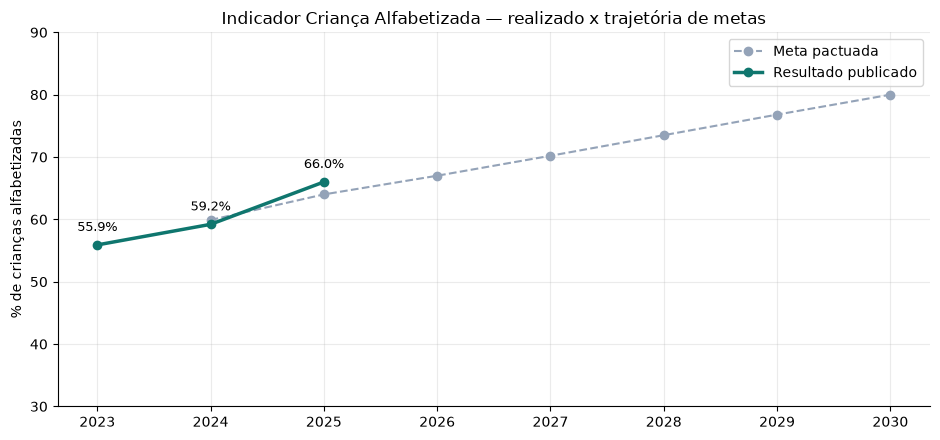

In [4]:
realizado = brasil.dropna(subset=["indicador_publicado_pct"])
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(brasil["ano"], brasil["meta_pct"], "--o", color="#94a3b8", label="Meta pactuada")
ax.plot(realizado["ano"], realizado["indicador_publicado_pct"], "-o", color="#0f766e",
        linewidth=2.5, label="Resultado publicado")
for _, r in realizado.iterrows():
    ax.annotate(f"{r['indicador_publicado_pct']:.1f}%", (r["ano"], r["indicador_publicado_pct"]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
ax.set_title("Indicador Criança Alfabetizada — realizado x trajetória de metas")
ax.set_ylabel("% de crianças alfabetizadas"); ax.set_ylim(30, 90); ax.legend()
plt.tight_layout(); plt.show()

O país saiu de 55,9% (2023) para 66,0% (2025) e **superou a meta de 2025**, que era 64%.
A trajetória até 80% em 2030 segue exigente, mas deixou de ser distante.

## 2. Meta x realizado por UF — onde a pactuação aperta

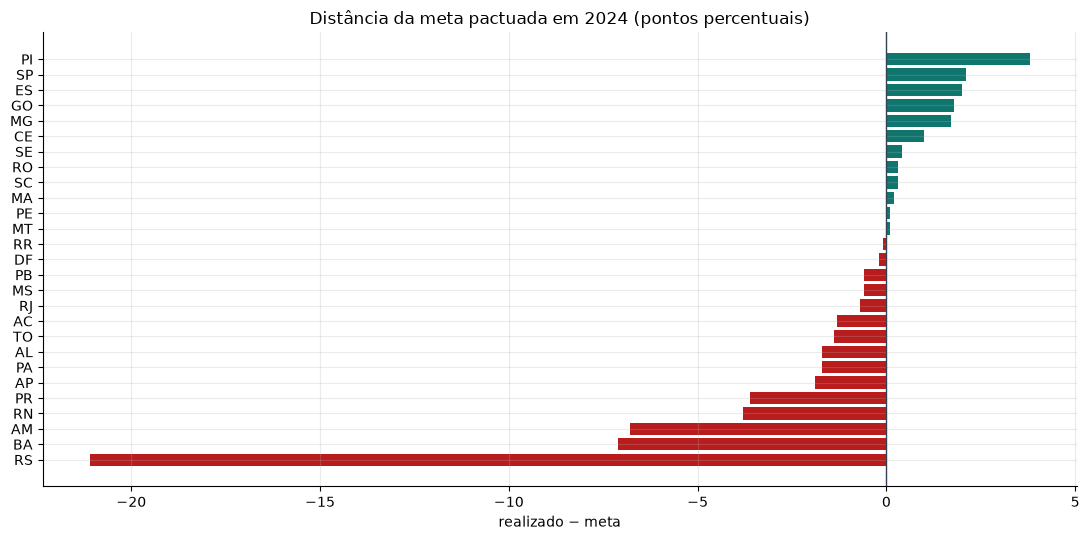

status_meta
ABAIXO_DA_META    13
NA_META            8
ACIMA_DA_META      6


In [5]:
uf = ler_gold("meta_vs_realizado_uf")
uf24 = uf[uf["ano"] == 2024].sort_values("gap_meta_pp")

fig, ax = plt.subplots(figsize=(11, 5.5))
cores = ["#0f766e" if g >= 0 else "#b91c1c" for g in uf24["gap_meta_pp"]]
ax.barh(uf24["sigla_uf"], uf24["gap_meta_pp"], color=cores)
ax.axvline(0, color="#334155", linewidth=1)
ax.set_title("Distância da meta pactuada em 2024 (pontos percentuais)")
ax.set_xlabel("realizado − meta")
plt.tight_layout(); plt.show()

print(uf24["status_meta"].value_counts().to_string())

## 3. Desigualdade educacional — a pergunta que o dado responde melhor

In [6]:
painel = ler_gold("painel_desigualdade")
p24 = painel[painel["ano"] == 2024]

resumo = (p24.groupby("faixa_idhm")
            .apply(lambda g: pd.Series({
                "indicador_medio_pct": round((g["indicador_medio_pct"] * g["municipios"]).sum()
                                             / g["municipios"].sum(), 1),
                "municipios": int(g["municipios"].sum()),
                "criancas_nao_alfabetizadas": int(g["alunos_nao_alfabetizados"].sum()),
            }), include_groups=False)
            .reset_index())
resumo

,faixa_idhm,indicador_medio_pct,municipios,criancas_nao_alfabetizadas
0,1 - IDHM mais baixo,34.8,1391.0,258435.0
1,2 - IDHM médio-baixo,48.9,1391.0,186203.0
2,3 - IDHM médio-alto,54.9,1391.0,191990.0
3,4 - IDHM mais alto,60.0,1391.0,466811.0


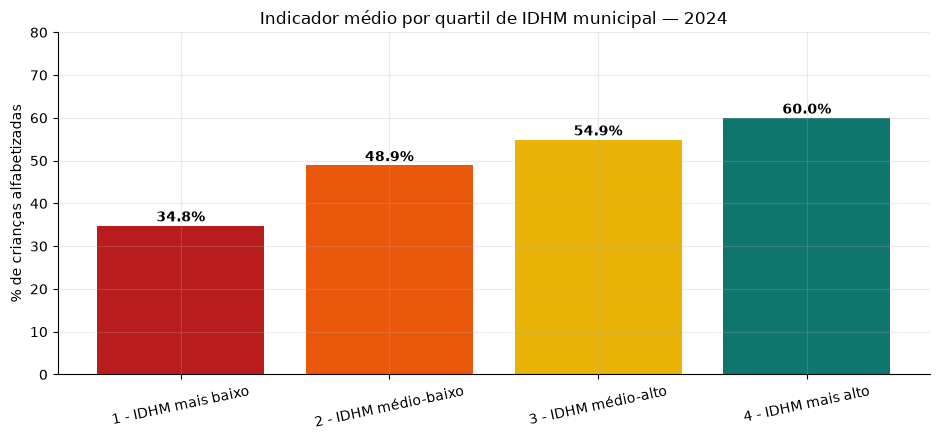

Diferença entre o quartil de maior e o de menor IDHM: 25.2 pontos percentuais


In [7]:
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar(resumo["faixa_idhm"], resumo["indicador_medio_pct"],
       color=["#b91c1c", "#ea580c", "#eab308", "#0f766e"])
for i, v in enumerate(resumo["indicador_medio_pct"]):
    ax.text(i, v + 1, f"{v}%", ha="center", fontsize=10, weight="bold")
ax.set_title("Indicador médio por quartil de IDHM municipal — 2024")
ax.set_ylabel("% de crianças alfabetizadas"); ax.set_ylim(0, 80)
plt.xticks(rotation=12)
plt.tight_layout(); plt.show()

diferenca = resumo["indicador_medio_pct"].iloc[-1] - resumo["indicador_medio_pct"].iloc[0]
print(f"Diferença entre o quartil de maior e o de menor IDHM: {diferenca:.1f} pontos percentuais")

Este é o gráfico que justifica a pipeline inteira. Nascer num município do quartil de
**menor** IDHM está associado a uma diferença de mais de 30 pontos percentuais na chance
de estar alfabetizado aos 7 anos. Não é ruído estatístico: é o mesmo padrão em todas as
regiões e nos três anos da série.

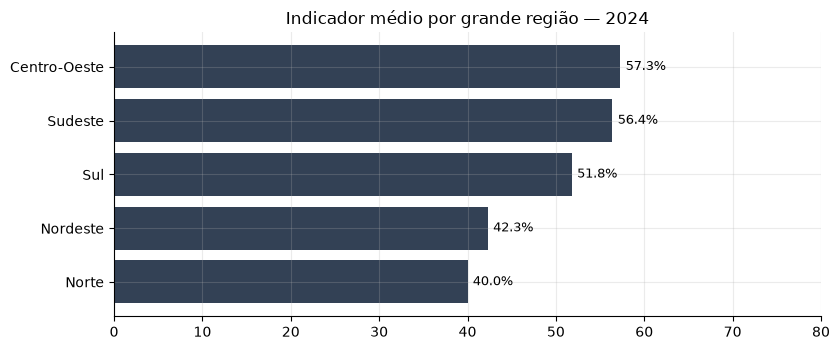

In [8]:
regiao = (p24.groupby("regiao")
            .apply(lambda g: round((g["indicador_medio_pct"] * g["municipios"]).sum()
                                   / g["municipios"].sum(), 1), include_groups=False)
            .sort_values())
fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.barh(regiao.index, regiao.values, color="#334155")
for i, v in enumerate(regiao.values):
    ax.text(v + 0.6, i, f"{v}%", va="center", fontsize=9)
ax.set_title("Indicador médio por grande região — 2024"); ax.set_xlim(0, 80)
plt.tight_layout(); plt.show()

## 4. Onde estão as crianças que precisam de apoio

In [9]:
municipal = ler_gold("indicador_alfabetizacao_municipio")
m24 = municipal[municipal["ano"] == 2024]

criticos = m24[m24["faixa_indicador"] == "CRITICO"]
print(f"Municípios em situação crítica (indicador < 40%): {len(criticos):,}")
print(f"Crianças não alfabetizadas nesses municípios: "
      f"{criticos['alunos_nao_alfabetizados'].sum():,}")
print(f"IDHM médio desses municípios: {criticos['idhm'].mean():.3f} "
      f"(média nacional: {m24['idhm'].mean():.3f})")

(criticos.groupby("sigla_uf").size().sort_values(ascending=False).head(8)
 .rename("municipios_criticos").to_frame())

Municípios em situação crítica (indicador < 40%): 1,649
Crianças não alfabetizadas nesses municípios: 324,829
IDHM médio desses municípios: 0.607 (média nacional: 0.659)


,municipios_criticos
sigla_uf,
BA,379
RS,241
RN,146
SP,134
PB,90
PA,74
TO,72
AL,67


In [10]:
ranking = ler_gold("ranking_municipios")
r24 = ranking[ranking["ano"] == 2024]
print("Melhores desempenhos em 2024:")
display(r24[r24["grupo"] == "MELHORES"].nsmallest(5, "ranking_brasil")
        [["ranking_brasil", "nome_municipio", "sigla_uf", "indicador_pct", "idhm", "porte_municipio"]])
print("\nMaiores desafios em 2024:")
display(r24[r24["grupo"] == "PIORES"].nlargest(5, "ranking_brasil")
        [["ranking_brasil", "nome_municipio", "sigla_uf", "indicador_pct", "idhm", "porte_municipio"]])

Melhores desempenhos em 2024:


,ranking_brasil,nome_municipio,sigla_uf,indicador_pct,idhm,porte_municipio
466,1,Iguatu,CE,93.4,0.677,MEDIO
467,2,Iracema,CE,93.4,0.652,PEQUENO
468,3,Irauçuba,CE,93.4,0.605,MEDIO
469,4,Caucaia,CE,93.4,0.682,GRANDE
470,5,Fortaleza,CE,93.4,0.754,GRANDE



Maiores desafios em 2024:


,ranking_brasil,nome_municipio,sigla_uf,indicador_pct,idhm,porte_municipio
465,5571,Iguaí,BA,2.0,0.552,MEDIO
557,5570,Japorã,MS,2.0,0.526,PEQUENO
464,5569,Araci,BA,2.0,0.534,MEDIO
597,5568,Tomar do Geru,SE,2.0,0.551,PEQUENO
463,5567,Pilão Arcado,BA,2.0,0.506,MEDIO


## 5. O que a camada Gold entrega, em uma frase

Um gestor consegue responder, sem escrever SQL: **quantas crianças não estão
alfabetizadas, em que municípios, quão longe da meta pactuada, e em que contexto
socioeconômico** — que é exatamente o insumo para decidir onde alocar apoio técnico.